In [2]:
from utils import variables, functions

# realod them (maybe have been updated)
import importlib
importlib.reload(functions)
importlib.reload(variables)

from sentence_transformers import SentenceTransformer
import os, json, numpy as np, pandas as pd, torch
from sklearn.cluster import AgglomerativeClustering
from nltk.corpus import wordnet as wn
from collections import defaultdict
from copy import copy
import matplotlib.pyplot as plt

Variables imported correctly.
Functions imported correctly.
Functions imported correctly.
Variables imported correctly.


In [3]:
#!pip install datalad

In [4]:
final_categories = variables.FINAL_CATEGORIES
final_categories

['object', 'animal or human', 'plant or food', 'scene']

In [5]:
# open scene_final_labels.txt
with open(os.path.join(variables.BOLD5000_PATH,'Image_Labels/scene_final_labels.txt'), 'r') as file:
    sun_labels = [line.strip() for line in file]
print(sun_labels[:5])

# open imagenet_final_labels.txt
with open(os.path.join(variables.BOLD5000_PATH,'Image_Labels/imagenet_final_labels.txt'), 'r') as file:
    imagenet_classes = [line.strip() for line in file]
# Extract only the classes names
imagenet_labels = list()
for el in imagenet_classes:
  class_name = el.split(' ')[1:]
  class_name = ' '.join(class_name)
  if class_name not in imagenet_labels:
    imagenet_labels.append(class_name)
print(imagenet_labels[:5])

# coco
with open("annotations/instances_val2017.json", "r") as f:
    coco_json = json.load(f)

# Extract official COCO label names
id2name_partial = {c['id']: c['name'] for c in coco_json['categories']}
coco_id2name = {i: id2name_partial.get(i) for i in range(0, 91)}
coco_id2name[0] = "background"

# Display the labels
coco_labels=[]
for cid, name in coco_id2name.items():
    coco_labels.append(name)
print(coco_labels[:5])

['readingroom', 'office', 'deck', 'promenadeDeck', 'MRI']
['tench, Tinca tinca', 'goldfish, Carassius auratus', 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', 'tiger shark, Galeocerdo cuvieri', 'hammerhead, hammerhead shark']
['background', 'person', 'bicycle', 'car', 'motorcycle']


#### MAPPING SUN TO FINAL CATEGORIES

In [ ]:
# assign SUN categories to the super categories

model = SentenceTransformer("all-MiniLM-L6-v2")

sun_embs = model.encode(sun_labels, convert_to_tensor=False, normalize_embeddings=True, show_progress_bar=True)
sup_embs  = model.encode(final_categories, convert_to_tensor=False, normalize_embeddings=True, show_progress_bar=True)

print(f'Length sun_labels: {len(sun_labels)} - Length final_categories: {len(final_categories)}')
print(f'Type sun_embs: {type(sun_embs)} - Shape: {sun_embs.shape} - Shape sun_embs[0]: {sun_embs[0].shape}')
print(f'Type sup_embs: {type(sup_embs)} - Shape: {sup_embs.shape} - Shape sup_embs[0]: {sup_embs[0].shape}')

# similarity matrix
sim = np.matmul(sup_embs, np.array(sun_embs).T)
print(f'Type sim: {type(sim)} - Shape: {sim.shape}')

# threshold to decide if assign or not assign
threshold = 0.45

assignments = {}
outliers    = []

# Assign each sun label to one and only one final category
for j, sun_lab in enumerate(sun_labels):
    # find the row that has the maximum similarity for the column j: find the final cat with the max similarity with sun label j
    best_i = np.argmax(sim[:,j])
    best_sim = sim[best_i, j]
    best_final_cat = final_categories[best_i]
    if best_sim >= threshold:
        assignments[sun_lab] = {
            'final_cat': best_final_cat,
            'similarity': float(best_sim)
        }
    else:
        outliers.append({
            'sun_category': sun_lab,
            'final_cat': best_final_cat,
            'similarity': float(best_sim)
        })

# Print results
print(f"✅ Assigned: {len(assignments)} SUN categories")
print(f"🚩 Outliers: {len(outliers)} SUN categories\n")

print("Examples of assignments:")
for sup, info in list(assignments.items())[:10]:
    print(f"  {sup:20s} → {info['final_cat']:15s}  (sim={info['similarity']:.2f})")

print("\nExamples of outlierss:")
for o in outliers[:20]:
    print(f"  {o['sun_category']:20s}  best match: {o['final_cat']:15s}  (sim={o['similarity']:.2f})")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Length sun_labels: 250 - Length final_categories: 4
Type sun_embs: <class 'numpy.ndarray'> - Shape: (250, 384) - Shape sun_embs[0]: (384,)
Type sup_embs: <class 'numpy.ndarray'> - Shape: (4, 384) - Shape sup_embs[0]: (384,)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 250)
✅ Assigned: 4 SUN categories
🚩 Outliers: 246 SUN categories

Examples of assignments:
  dinosaur             → animal or human  (sim=0.46)
  pantry               → plant or food    (sim=0.46)
  cabin                → scene            (sim=0.48)
  movie_theater        → scene            (sim=0.45)

Examples of outlierss:
  readingroom           best match: scene            (sim=0.25)
  office                best match: object           (sim=0.41)
  deck                  best match: scene            (sim=0.34)
  promenadeDeck         best match: scene            (sim=0.24)
  MRI                   best match: object           (sim=0.16)
  factory               best match: scene            (sim=0.44)
  sushibar        

This approach with the SUN dataset doesn't worl and it doesn't really make sense because the final_categories differ too much from the sun_labels, sin the SUN labels are all visual scenes, and no tobjects.

Let's analyze the type of labels of SUN dataset, grouping them in topics.

In [ ]:
# Embedding
model = SentenceTransformer('all-MiniLM-L6-v2')
embs = model.encode(sun_labels, normalize_embeddings=True, show_progress_bar=True)

# Clustering
n_topics = 10     
clusterer = AgglomerativeClustering(n_clusters=n_topics)
labels = clusterer.fit_predict(embs)

# Create groups from the clustering solution
topics = {i: [] for i in range(n_topics)}
for scene, c in zip(sun_labels, labels):
    topics[c].append(scene)

print("Clusters found:")
for i, group in topics.items():
    print(f"Topic {i+1}:", group)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Clusters found:
Topic 1: ['factory', 'sushibar', 'frontFoyer', 'garbagedump', 'horsebarn', 'bathroomSink', 'frontLawn', 'mallindoor', 'bar', 'appleorchard', 'dinosaur', 'ShowJumping', 'hometheater', 'windmill', 'HorseRaceTrack', 'golfcourse', 'wineVineyard', 'skislope', 'pizzeria', 'frontDoor', 'brewery', 'carmechanic', 'nailsalon', 'baywindow', 'bridalboutique', 'bikerack', 'homegarden', 'carwash', 'drycleaners', 'RVinside', 'ATM', 'chickenCoop', 'winebarrel', 'stripmall', 'chemicalplant', 'shower', 'barbershop', 'minigolf', 'hedgemaze', 'bistrooutdoor', 'hottub', 'cabana', 'pub', 'coffeeshop', 'homegarage', 'carFactory', 'cliff', 'racecarcourse', 'laundromat']
Topic 2: ['office', 'MRI', 'labClass', 'pharmacy', 'sculpturegarden', 'homeoffice', 'flowershop', 'nursery', 'artStudio', 'dancestudio', 'martialartsclass', 'childsroom', 'photographer_studio', 'cubicle', 'tailor', 'postoffice', 'constructionSite', 'dentist', 'tvstudio', 'kindergarten_classroom', 'shootingrange', 'doctor', 'apa

I decided to assign to all the SUN categories a final label "scene", and use it for the classification task.

In [8]:
# Assing to all SUN categories a super label: scene
sun_super_label = ['scene'] * len(sun_labels) # Create a list with 'scene' repeated 250 times
sun_final_df = pd.DataFrame()
sun_final_df['original_sun_name'] = sun_labels
sun_final_df['final_super_label'] = sun_super_label

print(f'Number of final labels: {len(sun_final_df["final_super_label"].unique())}')
print(f'Shape of the df: {sun_final_df.shape}')
sun_final_df.head(5)

Number of final labels: 1
Shape of the df: (250, 2)


,original_sun_name,final_super_label
0,readingroom,scene
1,office,scene
2,deck,scene
3,promenadeDeck,scene
4,MRI,scene


#### MAPPING COCO TO FINAL CATEGORIES

In [ ]:
# assign SUN categories to the super categories

# Remove None from coco_labels
coco_labels_temp = [label for label in coco_labels if label is not None]

model = SentenceTransformer("all-MiniLM-L6-v2")

coco_embs = model.encode(coco_labels_temp, convert_to_tensor=False, normalize_embeddings=True, show_progress_bar=True)
sup_embs  = model.encode(final_categories, convert_to_tensor=False, normalize_embeddings=True, show_progress_bar=True)

print(f'Length coco_labels: {len(coco_labels_temp)} - Length final_categories: {len(final_categories)}')
print(f'Type coco_embs: {type(coco_embs)} - Shape: {coco_embs.shape} - Shape coco_embs[0]: {coco_embs[0].shape}')
print(f'Type sup_embs: {type(sup_embs)} - Shape: {sup_embs.shape} - Shape sup_embs[0]: {sup_embs[0].shape}')

# similarity matrix
sim = np.matmul(sup_embs, np.array(coco_embs).T)
print(f'Type sim: {type(sim)} - Shape: {sim.shape}')

# threshold to decide if assign or not assign
threshold = 0.4

assignments = {}
outliers    = []

# Assign each sun label to one and only one final category
for j, coco_lab in enumerate(coco_labels_temp):
    # find the row that has the maximum similarity for the column j: find the final cat with the max similarity with sun label j
    best_i = np.argmax(sim[:,j])
    best_sim = sim[best_i, j]
    best_final_cat = final_categories[best_i]
    if best_sim >= threshold:
        assignments[coco_lab] = {
            'final_cat': best_final_cat,
            'similarity': float(best_sim)
        }
    else:
        outliers.append({
            'coco_category': coco_lab,
            'final_cat': best_final_cat,
            'similarity': float(best_sim)
        })

# Print results
print(f"✅ Assigned: {len(assignments)} COCO categories")
print(f"🚩 Outliers: {len(outliers)} COCO categories\n")

print("Examples of assignments:")
for sup, info in list(assignments.items())[:10]:
    print(f"  {sup:20s} → {info['final_cat']:15s}  (sim={info['similarity']:.2f})")

print("\nExamples of outlierss:")
for o in outliers[:20]:
    print(f"  {o['coco_category']:20s}  best match: {o['final_cat']:15s}  (sim={o['similarity']:.2f})")

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Length coco_labels: 81 - Length final_categories: 4
Type coco_embs: <class 'numpy.ndarray'> - Shape: (81, 384) - Shape coco_embs[0]: (384,)
Type sup_embs: <class 'numpy.ndarray'> - Shape: (4, 384) - Shape sup_embs[0]: (384,)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 81)
✅ Assigned: 31 COCO categories
🚩 Outliers: 50 COCO categories

Examples of assignments:
  background           → scene            (sim=0.48)
  person               → object           (sim=0.53)
  bicycle              → object           (sim=0.41)
  car                  → object           (sim=0.54)
  airplane             → object           (sim=0.44)
  truck                → object           (sim=0.41)
  bird                 → animal or human  (sim=0.48)
  cat                  → animal or human  (sim=0.50)
  dog                  → animal or human  (sim=0.57)
  horse                → animal or human  (sim=0.49)

Examples of outlierss:
  motorcycle            best match: object           (sim=0.38)
  bus             

It does not work well, so we can try to use texts instead of single words.

In [10]:
final_categories

['object', 'animal or human', 'plant or food', 'scene']

In [11]:
texts_cat = {
    "object": [
        "a photo of an object",
        "a photo of a tool or appliance",
        "a photo of a piece of furniture",
        "a photo of a manufactured object",
        "a photo of a vehicle"
    ],
    "animal or human": [
        "a photo of an animal",
        "a photo of a pet",
        "a photo of a mammal or bird",
        "a photo of a family member",
        "a photo of a person",
        "a photo of a human"
    ],
    "plant or food": [
        "a photo of a plant",
        "a photo of a flower",
        "a photo of a tree or grass",
        "a photo of food",
        "a photo of an edible food or drink",
        "a photo of a meal or snack",
        "a photo of a fruit or vegetable"
    ],
    # natural scene
   "scene": [
        "a photo of a natural view",
        "a photo of a mountain",
        "a photo of sea",
        "a photo of indoor"
    ]
}

final_names = list(texts_cat.keys())

proto_embs = []
for fn in final_names:
    texts = texts_cat[fn]
    embs = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True)
    # average in euclidean space then renormalize (cosine mean)
    mean_emb = torch.mean(embs, dim=0)
    mean_emb = mean_emb / mean_emb.norm(p=2)
    proto_embs.append(mean_emb)
proto_embs = torch.stack(proto_embs)   # shape [n_final, D]
print(f'Type proto_embs: {type(proto_embs)} - Shape: {proto_embs.shape}')
# from torch to numpy
proto_embs = proto_embs.cpu().numpy()
print(f'Type proto_embs: {type(proto_embs)} - Shape: {proto_embs.shape}')

coco_texts = [f'a photo of {el}' for el in coco_labels_temp]
coco_texts[:10]

Type proto_embs: <class 'torch.Tensor'> - Shape: torch.Size([4, 384])
Type proto_embs: <class 'numpy.ndarray'> - Shape: (4, 384)


['a photo of background',
 'a photo of person',
 'a photo of bicycle',
 'a photo of car',
 'a photo of motorcycle',
 'a photo of airplane',
 'a photo of bus',
 'a photo of train',
 'a photo of truck',
 'a photo of boat']

In [ ]:
# assign coco categories to the super categories

# Remove None from coco labels
coco_labels_temp = [label for label in coco_labels if label is not None]

model = SentenceTransformer("all-MiniLM-L6-v2")

coco_embs = model.encode(coco_labels_temp, convert_to_tensor=False, normalize_embeddings=True, show_progress_bar=True)

print(f'Length coco_labels: {len(coco_labels_temp)} - Length final_categories: {len(final_categories)}')
print(f'Type coco_embs: {type(coco_embs)} - Shape: {coco_embs.shape} - Shape coco_embs[0]: {coco_embs[0].shape}')
print(f'Type proto_embs: {type(proto_embs)} - Shape: {proto_embs.shape} - Shape proto_embs[0]: {proto_embs[0].shape}')

# similarity matrix
sim = np.matmul(proto_embs, np.array(coco_embs).T)
print(f'Type sim: {type(sim)} - Shape: {sim.shape}')

# threshold to decide if assign or not assign
threshold = 0.4

assignments = {}
outliers    = []

# Assign each sun label to one and only one final category
for j, coco_lab in enumerate(coco_labels_temp):
    # find the row that has the maximum similarity for the column j: find the final cat with the max similarity with sun label j
    best_i = np.argmax(sim[:,j])
    best_sim = sim[best_i, j]
    best_final_cat = final_categories[best_i]
    if best_sim >= threshold:
        assignments[coco_lab] = {
            'final_cat': best_final_cat,
            'similarity': float(best_sim)
        }
    else:
        outliers.append({
            'coco_category': coco_lab,
            'final_cat': best_final_cat,
            'similarity': float(best_sim)
        })

# Print results
print(f"✅ Assigned: {len(assignments)} COCO categories")
print(f"🚩 Outliers: {len(outliers)} COCO categories\n")

print("Examples of assignments:")
for sup, info in list(assignments.items())[:10]:
    print(f"  {sup:20s} → {info['final_cat']:15s}  (sim={info['similarity']:.2f})")

print("\nExamples of outlierss:")
for o in outliers[:20]:
    print(f"  {o['coco_category']:20s}  best match: {o['final_cat']:15s}  (sim={o['similarity']:.2f})")

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Length coco_labels: 81 - Length final_categories: 4
Type coco_embs: <class 'numpy.ndarray'> - Shape: (81, 384) - Shape coco_embs[0]: (384,)
Type proto_embs: <class 'numpy.ndarray'> - Shape: (4, 384) - Shape proto_embs[0]: (384,)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 81)
✅ Assigned: 5 COCO categories
🚩 Outliers: 76 COCO categories

Examples of assignments:
  background           → scene            (sim=0.41)
  person               → animal or human  (sim=0.44)
  bird                 → animal or human  (sim=0.42)
  dog                  → animal or human  (sim=0.40)
  potted plant         → plant or food    (sim=0.41)

Examples of outlierss:
  bicycle               best match: scene            (sim=0.27)
  car                   best match: object           (sim=0.36)
  motorcycle            best match: object           (sim=0.27)
  airplane              best match: scene            (sim=0.27)
  bus                   best match: object           (sim=0.20)
  train                 

It seems to work well. 
Also in the outliers, I just have to lower the threshold. The problem though, is that COCO has multi-labels images, that is, each image containes multiple objects. It complicates the problem, and since I want to do a single-label classification task, for now, I will not consider fMRI data taken from COCO stimuli. 

I will only data obtained using ImageNet and SUN images.

#### MAPPING IMAGENET TO FINAL CATEGORIES

##### Approach: NLTK

I'll define a function which finds the hypernyms of each ImageNet label, and then use a sentence transformer to group them in the final labels. 

In [6]:
# Download corpus Wordnet, VERY important for the below cells
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/mambauser/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
imagenet_labels[:5]

['tench, Tinca tinca',
 'goldfish, Carassius auratus',
 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 'tiger shark, Galeocerdo cuvieri',
 'hammerhead, hammerhead shark']

In [8]:
# Create a df with category_id and category_name
# category_id is the number before the words ,. like n01440764
imagenet_df = pd.DataFrame()
imagenet_df['category_id'] = [(label.split(' ')[0]) for label in imagenet_classes]
imagenet_df['category_name'] = [(label.split(' ')[1:]) for label in imagenet_classes]
# join the words in category_name. They have to be a sdingle string, not a list of strings
imagenet_df['category_name'] = imagenet_df['category_name'].apply(lambda x: ' '.join(x))
imagenet_df.head(5)

,category_id,category_name
0,n01440764,"tench, Tinca tinca"
1,n01443537,"goldfish, Carassius auratus"
2,n01484850,"great white shark, white shark, man-eater, man..."
3,n01491361,"tiger shark, Galeocerdo cuvieri"
4,n01494475,"hammerhead, hammerhead shark"


In [9]:
# Each synset provides definitions, examples and relationships to other synsets.
# Each synset represent unique concepts.

def wnid_to_synset(wnid):
    '''
    Args:
        wnid: wordnet id (e.g. n01440764)
    Returns the corresponding synset.
    '''
    pos = wnid[0]               # pos = 'n'
    offset = int(wnid[1:])      # offset = the ciphers after 'n'
    
    # DEBUG
    #print(pos,offset)
    
    try:
        synset = wn.synset_from_pos_and_offset(pos, offset)
        return synset
    except:
        return None

def get_supercategory(synset, level=3):
    '''
    Args:
        synset: wordnet synset.
        level: level to reach in the hierarchy.
    Returns the hypernym at level level of the synset in input.
    '''
    if synset is None:
        return None
    hypernym_paths = synset.hypernym_paths()
    if not hypernym_paths:
        return None
    path = hypernym_paths[0]
    if len(path) > level:
        return path[level]
    else:
        return path[-1]

In [10]:
imagenet_wnids = list(imagenet_df['category_id'])
print(f'Imagenet ids examples: {imagenet_wnids[:5]}')

fine_to_coarse = {}
for i, wnid in enumerate(imagenet_wnids):
      synset = wnid_to_synset(wnid)
      supercat = get_supercategory(synset, level=9)
      coarse_name = supercat.name() if supercat else None
      fine_to_coarse[wnid] = coarse_name
      print(f'Example: wnid: {wnid} --> synset: {synset} --> supercat: {supercat} --> coarse_name: {coarse_name}')  if i==1 else None

Imagenet ids examples: ['n01440764', 'n01443537', 'n01484850', 'n01491361', 'n01494475']
Example: wnid: n01443537 --> synset: Synset('goldfish.n.01') --> supercat: Synset('aquatic_vertebrate.n.01') --> coarse_name: aquatic_vertebrate.n.01


In [11]:
# Let's see an example of synsets and its hypernims and hyponims
print(f'Synset: {synset}')      # take the last synset of the cell above

# Hypernyms (general terms)
print(f'Hypernyms: {synset.hypernyms()}') 

# Hyponyms (specific terms)
print(f'Hyponyms: {synset.hyponyms()}\n') 

# Hypernyms chain
hypernyms_list = []
syn = copy(synset)
for i in range(8):
    hypernyms = syn.hypernyms()
    if not hypernyms:
        break
    syn = hypernyms[0]      # the hypernyms are returned ad lists
    hypernyms_list.append(syn)
print(hypernyms_list)

Synset: Synset('toilet_tissue.n.01')
Hypernyms: [Synset('tissue.n.02')]
Hyponyms: [Synset('toilet_roll.n.01')]

[Synset('tissue.n.02'), Synset('paper.n.01'), Synset('material.n.01'), Synset('substance.n.01'), Synset('part.n.01'), Synset('relation.n.01'), Synset('abstraction.n.06'), Synset('entity.n.01')]


In [12]:
# Try with different levels
print(f'Synset: {synset}')
for lev in [0,1,2,3,4,5,6,7,8,9,10]:
      supercat = get_supercategory(synset, level=lev)
      coarse_name = supercat.name() if supercat else None
      print(f'  Level {lev} --> supercat: {supercat}')

Synset: Synset('toilet_tissue.n.01')
  Level 0 --> supercat: Synset('entity.n.01')
  Level 1 --> supercat: Synset('abstraction.n.06')
  Level 2 --> supercat: Synset('relation.n.01')
  Level 3 --> supercat: Synset('part.n.01')
  Level 4 --> supercat: Synset('substance.n.01')
  Level 5 --> supercat: Synset('material.n.01')
  Level 6 --> supercat: Synset('paper.n.01')
  Level 7 --> supercat: Synset('tissue.n.02')
  Level 8 --> supercat: Synset('toilet_tissue.n.01')
  Level 9 --> supercat: Synset('toilet_tissue.n.01')
  Level 10 --> supercat: Synset('toilet_tissue.n.01')


The higher the level, the more general is the hypernym found. We have to think to the hierarchy as a tree. In the bottom part, just one synset: 'entity', in the upper levels, more specific synsets.

In [13]:
# Let's analyze synonyms
lemmas = synset.lemmas()
print([lemma.name() for lemma in lemmas]) 

synset = wn.synset('tench.n.01')
lemmas = synset.lemmas()
print([lemma.name() for lemma in lemmas]) 

['toilet_tissue', 'toilet_paper', 'bathroom_tissue']
['tench', 'Tinca_tinca']


- Path similarity is based on the length of the path between two synsets. 
$$
\text{path\_similarity}(s_1, s_2) = \frac{1}{\text{path\_length}(s_1, s_2) + 1}
$$
--> the longer the distance, the less the similarity   

- Wu Palmer similarity is based on the depth of the Least Common Subsumer (LCS), that is the common ancestor most deep.
$$
\text{wup\_similarity}(s_1, s_2) = \frac{\text{2 x depth(LCS)}}{\text{depth(s1)} + \text{depth(s2)}}
$$

In [14]:
# Similarity
material = wn.synset('material.n.01')
tissue = wn.synset('tissue.n.02')

# Path similarity (based on taxonomy path length)
print(material.path_similarity(tissue)) 
# the path from material to tissue is long 2 --> 1/3 = 0.33

# Wu-Palmer similarity (based on common ancestor depth)
depth_s1 = material.min_depth()
depth_s2 = tissue.min_depth()
lcs = material.lowest_common_hypernyms(tissue)
depth_lcs = lcs[0].min_depth() if lcs else None
print(f"\nDepth material: {depth_s1}, Depth tissue: {depth_s2}, Depth LCS: {depth_lcs}")
print(material.wup_similarity(tissue)) 


0.3333333333333333

Depth material: 4, Depth tissue: 6, Depth LCS: 4
0.8571428571428571


In [25]:
if True:
  mappings_different_levels = []

  levels = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

  for lev in levels:
    fine_to_coarse = {}
    for wnid in imagenet_wnids:
      synset = wnid_to_synset(wnid)
      supercat = get_supercategory(synset, level=lev)
      coarse_name = supercat.name() if supercat else None
      fine_to_coarse[wnid] = coarse_name
    mappings_different_levels.append(fine_to_coarse)

  # Create super categories
  for fine_to_coarse in mappings_different_levels:
    super_categories = defaultdict(list)
    for fine, coarse in fine_to_coarse.items():
        super_categories[coarse].append(fine)
  
  print(f'Levels analyzed: {levels}\n')

  for lev, fine_to_coarse in zip(levels, mappings_different_levels):
      super_categories = defaultdict(list)
      for fine, coarse in fine_to_coarse.items():
          super_categories[coarse].append(fine)
      print(f'  Level {lev:2d}: {len(super_categories)} super categories')

Levels analyzed: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

  Level  2: 6 super categories
  Level  3: 12 super categories
  Level  4: 20 super categories
  Level  5: 38 super categories
  Level  6: 85 super categories
  Level  7: 216 super categories
  Level  8: 355 super categories
  Level  9: 500 super categories
  Level 10: 620 super categories
  Level 11: 762 super categories
  Level 12: 839 super categories
  Level 13: 896 super categories
  Level 14: 940 super categories
  Level 15: 955 super categories
  Level 16: 958 super categories
  Level 17: 958 super categories


In [ ]:
texts_cat = {
    "object": [
        "a photo of an object",
        "a photo of a tool or appliance",
        "a photo of a piece of furniture",
        "a photo of a manufactured object",
        "a photo of a vehicle",
        "a photo of a tool"
    ],
    "animal or human": [
        "a photo of an animal",
        "a photo of a pet",
        "a photo of a mammal or bird",
        "a photo of a family member",
        "a photo of a person",
        "a photo of a human",
        "a photo of a fish",
        "a photo of a insect"
    ],
    "plant or food": [
        "a photo of a green plant",
        "a photo of a flower",
        "a photo of a tree or grass",
        "a photo of food",
        "a photo of an edible food or drink",
        "a photo of a meal or snack",
        "a photo of a fruit or vegetable",
        "a photo of flora",
        "a photo of nutriment"
    ],
    # natural scene
   "scene": [
        "a photo of a natural view",
        "a photo of a mountain",
        "a photo of sea",
        "a photo of indoor"
    ]
}

final_names = list(texts_cat.keys())

proto_embs = []
for fn in final_names:
    texts = texts_cat[fn]
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embs = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True)

    mean_emb = torch.mean(embs, dim=0)
    mean_emb = mean_emb / mean_emb.norm(p=2)
    proto_embs.append(mean_emb)
proto_embs = torch.stack(proto_embs)   # shape [n_final, D]
print(f'Type proto_embs: {type(proto_embs)} - Shape: {proto_embs.shape}')
# from torch to numpy
proto_embs = proto_embs.cpu().numpy()
print(f'Type proto_embs: {type(proto_embs)} - Shape: {proto_embs.shape}')

Type proto_embs: <class 'torch.Tensor'> - Shape: torch.Size([4, 384])
Type proto_embs: <class 'numpy.ndarray'> - Shape: (4, 384)


In [27]:
if True:
  ratios = []   # list to store ratios between assigned and total categories for each generalization level

  for lev, fine_to_coarse in zip(levels, mappings_different_levels):
      imagenet_classes_second_approach = list({c for c in fine_to_coarse.values()})
      imagenet_texts = [f'a photo of {el.split('.')[0]}' for el in imagenet_classes_second_approach]
imagenet_texts[:10]

['a photo of macaw',
 'a photo of cauliflower',
 'a photo of cheetah',
 'a photo of madagascar_cat',
 'a photo of wok',
 'a photo of dugong',
 'a photo of chickadee',
 'a photo of pembroke',
 'a photo of digital_watch',
 'a photo of mortarboard']

In [28]:
if True:
  ratios = []   # list to store ratios between assigned and total categories for each generalization level

  for lev, fine_to_coarse in zip(levels, mappings_different_levels):
      imagenet_classes_second_approach = list({c for c in fine_to_coarse.values()})
      print(imagenet_classes_second_approach)
      imagenet_texts = [f'a photo of {el.split('.')[0]}' for el in imagenet_classes_second_approach]

      # Assign each imagenet label to one of the 177 super labels obtained in the cells above
      model = SentenceTransformer("all-MiniLM-L6-v2")

      imagenet_embs = model.encode(imagenet_texts, convert_to_tensor=False, normalize_embeddings=True, show_progress_bar=True)
      
      sim = np.matmul(proto_embs, np.array(imagenet_embs).T)
      print(f'Lev: {lev} - Shape imagenet_embs: {imagenet_embs.shape}')
      print(f'Type sim: {type(sim)} - Shape: {sim.shape}')

      # threshold to decide if assign or not assign
      threshold = 0.5

      assignments = {}
      outliers    = []

      imagenet_super_mapping = {}

      for j, img_lab in enumerate(imagenet_classes_second_approach):
          best_i = np.argmax(sim[:,j])
          best_sim = sim[best_i, j]
          best_final_cat = variables.FINAL_CATEGORIES[best_i]
          if best_sim >= threshold:
              assignments[img_lab] = {
                  'unique_super': variables.FINAL_CATEGORIES[best_i],
                  'similarity': float(best_sim)
              }
              imagenet_super_mapping[img_lab] = best_final_cat
          else:
              outliers.append({
                  'imagenet_category': img_lab,
                  'best_unique_super': best_final_cat,
                  'similarity': best_sim
              })

      # Print results:
      print(f"Level {lev:2d}, len: {len(imagenet_classes_second_approach)}:")
      print(f"✅ Assigned: {len(assignments)} ImageNet categories")
      print(f"🚩 Outliers: {len(outliers)} ImageNet categories")

      ratio = len(assignments)/len(imagenet_classes_second_approach)
      ratios.append(ratio)
      print(f"Ratio: {ratio}\n\n")

['attribute.n.02', 'causal_agent.n.01', 'object.n.01', 'relation.n.01', 'matter.n.03', 'communication.n.02']


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Lev: 2 - Shape imagenet_embs: (6, 384)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 6)
Level  2, len: 6:
✅ Assigned: 5 ImageNet categories
🚩 Outliers: 1 ImageNet categories
Ratio: 0.8333333333333334


['geological_formation.n.01', 'part.n.01', 'part.n.02', 'whole.n.02', 'person.n.01', 'agent.n.03', 'sign.n.02', 'signal.n.01', 'substance.n.07', 'solid.n.01', 'shape.n.02', 'location.n.01']


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Lev: 3 - Shape imagenet_embs: (12, 384)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 12)
Level  3, len: 12:
✅ Assigned: 12 ImageNet categories
🚩 Outliers: 0 ImageNet categories
Ratio: 1.0


['street_sign.n.01', 'living_thing.n.01', 'natural_elevation.n.01', 'point.n.02', 'food.n.01', 'round_shape.n.01', 'peer.n.01', 'piece.n.01', 'visual_signal.n.01', 'cliff.n.01', 'natural_object.n.01', 'artifact.n.01', 'shore.n.01', 'natural_depression.n.01', 'spring.n.03', 'drug.n.01', 'food.n.02', 'contestant.n.01', 'substance.n.01', 'explorer.n.01']


...

Lev: 15 - Shape imagenet_embs: (955, 384)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 955)
Level 15, len: 955:
✅ Assigned: 790 ImageNet categories
🚩 Outliers: 165 ImageNet categories
Ratio: 0.8272251308900523


['macaw.n.01', 'cauliflower.n.02', 'cheetah.n.01', 'madagascar_cat.n.01', 'wok.n.01', 'wild_goat.n.01', 'dugong.n.01', 'chickadee.n.01', 'pembroke.n.01', 'digital_watch.n.01', 'mortarboard.n.02', 'entlebucher.n.01', 'french_bulldog.n.01', 'jinrikisha.n.01', 'shower_curtain.n.01', 'grille.n.02', 'briard.n.01', 'airship.n.01', 'cliff_dwelling.n.01', 'dutch_oven.n.01', 'sandal.n.01', 'walking_stick.n.02', 'doberman.n.01', 'prayer_rug.n.01', 'llama.n.01', 'brass.n.07', 'pekinese.n.01', 'combination_lock.n.01', 'balloon.n.01', 'police_van.n.01', 'thatch.n.04', 'cardoon.n.02', 'jackfruit.n.02', 'coral_fungus.n.01', 'dial_telephone.n.01', 'king_crab.n.03', 'king_penguin.n.01', 'leaf_beetle.n.01', 'jigsaw_puzzle.n.01', 'notebook.n.02', 'volcano.n.02', 'armadillo.n.01', 'wardrobe.n.01

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Lev: 16 - Shape imagenet_embs: (958, 384)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 958)
Level 16, len: 958:
✅ Assigned: 790 ImageNet categories
🚩 Outliers: 168 ImageNet categories
Ratio: 0.824634655532359


['macaw.n.01', 'cauliflower.n.02', 'cheetah.n.01', 'madagascar_cat.n.01', 'wok.n.01', 'dugong.n.01', 'chickadee.n.01', 'pembroke.n.01', 'digital_watch.n.01', 'mortarboard.n.02', 'entlebucher.n.01', 'french_bulldog.n.01', 'jinrikisha.n.01', 'shower_curtain.n.01', 'grille.n.02', 'briard.n.01', 'airship.n.01', 'cliff_dwelling.n.01', 'dutch_oven.n.01', 'sandal.n.01', 'walking_stick.n.02', 'doberman.n.01', 'prayer_rug.n.01', 'llama.n.01', 'brass.n.07', 'pekinese.n.01', 'combination_lock.n.01', 'balloon.n.01', 'police_van.n.01', 'thatch.n.04', 'cardoon.n.02', 'jackfruit.n.02', 'coral_fungus.n.01', 'dial_telephone.n.01', 'king_crab.n.03', 'king_penguin.n.01', 'leaf_beetle.n.01', 'jigsaw_puzzle.n.01', 'bighorn.n.02', 'notebook.n.02', 'volcano.n.02', 'armadillo.n.01', 'wardrobe.n.01', 

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Lev: 17 - Shape imagenet_embs: (958, 384)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 958)
Level 17, len: 958:
✅ Assigned: 788 ImageNet categories
🚩 Outliers: 170 ImageNet categories
Ratio: 0.8225469728601252




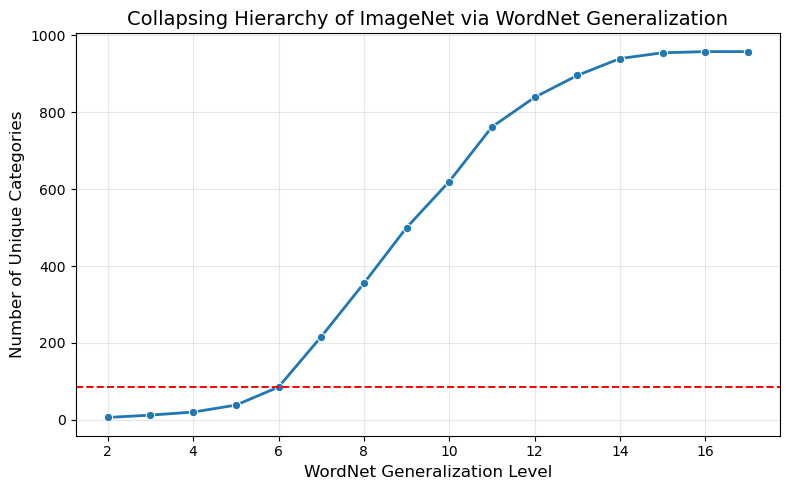

In [ ]:
import seaborn as sns

# Compute number of unique categories at each generalization level
n_categories = []

for lev, fine_to_coarse in zip(levels, mappings_different_levels):
    unique_cats = list({c for c in fine_to_coarse.values()})
    n_categories.append(len(unique_cats))

# Plot
plt.figure(figsize=(8,5))
sns.lineplot(x=levels, y=n_categories, marker="o", linewidth=2)

y_level6 = n_categories[levels.index(6)]
plt.axhline(y=y_level6, color='red', linestyle='--', linewidth=1.4)

plt.title("Collapsing Hierarchy of ImageNet via WordNet Generalization", fontsize=14)
plt.xlabel("WordNet Generalization Level", fontsize=12)
plt.ylabel("Number of Unique Categories", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
imagenet_wnids = list(imagenet_df['category_id'])
print(f'Imagenet ids examples: {imagenet_wnids[:5]}')

fine_to_coarse = {}
for i, wnid in enumerate(imagenet_wnids):
      synset = wnid_to_synset(wnid)
      supercat = get_supercategory(synset, level=9)
      coarse_name = supercat.name() if supercat else None
      fine_to_coarse[wnid] = coarse_name
      print(f'Example: wnid: {wnid} --> synset: {synset} --> supercat: {supercat} --> coarse_name: {coarse_name}')  if i==1 else None

Imagenet ids examples: ['n01440764', 'n01443537', 'n01484850', 'n01491361', 'n01494475']
Example: wnid: n01443537 --> synset: Synset('goldfish.n.01') --> supercat: Synset('aquatic_vertebrate.n.01') --> coarse_name: aquatic_vertebrate.n.01


In [27]:
# I will use a level with a good ratio but not with too few labels
lev = 6

fine_to_coarse = {}
for wnid in imagenet_wnids:
      synset = wnid_to_synset(wnid)
      supercat = get_supercategory(synset, level=lev)
      coarse_name = supercat.name() if supercat else None
      fine_to_coarse[wnid] = coarse_name


# Create super categories
super_categories = defaultdict(list)
for fine, coarse in fine_to_coarse.items():
      super_categories[coarse].append(fine)

print(f'Level of generalization with the highest ratio: {lev}')
print(f'Number of supercategories obtained: {len(super_categories)}')


imagenet_classes_second_approach = list({c for c in fine_to_coarse.values()})
print(imagenet_classes_second_approach)
imagenet_texts = [f'a photo of {el.split('.')[0]}' for el in imagenet_classes_second_approach]

# Assign each imagenet label to one of the 177 super labels obtained in the cells above
model = SentenceTransformer("all-MiniLM-L6-v2")

if True:
      imagenet_embs = model.encode(imagenet_texts, convert_to_tensor=False, normalize_embeddings=True, show_progress_bar=True)
      
      sim = np.matmul(proto_embs, np.array(imagenet_embs).T)
      print(f'Lev: {lev} - Shape imagenet_embs: {imagenet_embs.shape}')
      print(f'Type sim: {type(sim)} - Shape: {sim.shape}')

      # threshold to decide if assign or not assign
      threshold = 0.3

      assignments = {}
      outliers    = []

      imagenet_super_mapping = {}

      for j, img_lab in enumerate(imagenet_classes_second_approach):
          best_i = np.argmax(sim[:,j])
          best_sim = sim[best_i, j]
          best_final_cat = variables.FINAL_CATEGORIES[best_i]
          if best_sim >= threshold:
              assignments[img_lab] = {
                  'unique_super': variables.FINAL_CATEGORIES[best_i],
                  'similarity': float(best_sim)
              }
              imagenet_super_mapping[img_lab] = best_final_cat
          else:
              outliers.append({
                  'imagenet_category': img_lab,
                  'best_unique_super': best_final_cat,
                  'similarity': best_sim
              })

      # Print results:
      print(f"Level {lev:2d}, len: {len(imagenet_classes_second_approach)}:")
      print(f"✅ Assigned: {len(assignments)} ImageNet categories")
      print(f"🚩 Outliers: {len(outliers)} ImageNet categories")
    
print("Examples of assignments:")
for sup, info in list(assignments.items()):
      print(f"  {sup:50s} → {info['unique_super']:30}  (sim={info['similarity']:.2f})")

print("\nExamples of outliers:")
if len(outliers)!=0:
      for o in outliers[:20]:
          print(f"  {o['imagenet_category']:50s}  best match: {o['best_unique_super']:15s}  (sim={o['similarity']:.2f})")
else:
    print('All ImageNet categories have been assigned to one super category.')

Level of generalization with the highest ratio: 6
Number of supercategories obtained: 80
['velvet.n.01', 'reef.n.01', 'supporting_structure.n.01', 'ball.n.03', 'ingredient.n.03', 'cloth_covering.n.01', 'wool.n.01', 'participant.n.01', 'geyser.n.01', 'equipment.n.01', 'plant.n.02', 'volcano.n.02', 'seashore.n.01', 'scuba_diver.n.01', 'powder.n.03', 'cloak.n.01', 'fungus.n.01', 'course.n.07', 'concoction.n.01', 'tower.n.01', 'cliff.n.01', 'housing.n.01', 'device.n.01', 'column.n.06', 'obstruction.n.01', 'street_sign.n.01', 'protective_covering.n.01', 'conveyance.n.03', 'bar.n.08', 'paper.n.01', 'lakeside.n.01', 'horizontal_surface.n.01', 'ware.n.01', 'fodder.n.02', 'container.n.01', 'connection.n.03', 'vegetable.n.01', 'defensive_structure.n.01', 'dish.n.02', 'area.n.05', 'implement.n.01', 'memorial.n.03', 'system.n.01', 'valley.n.01', 'landing.n.02', 'toiletry.n.01', 'floor_cover.n.01', 'piece_of_cloth.n.01', 'design.n.04', 'medium.n.01', 'building_complex.n.01', 'menu.n.02', 'plant_org

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Lev: 6 - Shape imagenet_embs: (80, 384)
Type sim: <class 'numpy.ndarray'> - Shape: (4, 80)
Level  6, len: 80:
✅ Assigned: 80 ImageNet categories
🚩 Outliers: 0 ImageNet categories
Examples of assignments:
  velvet.n.01                                        → animal or human                 (sim=0.54)
  reef.n.01                                          → scene                           (sim=0.62)
  supporting_structure.n.01                          → object                          (sim=0.58)
  ball.n.03                                          → object                          (sim=0.62)
  ingredient.n.03                                    → plant or food                   (sim=0.70)
  cloth_covering.n.01                                → object                          (sim=0.52)
  wool.n.01                                          → scene                           (sim=0.52)
  participant.n.01                                   → animal or human                 (sim=0.71)
  geyser.n.0

In [28]:
# update imagenet_df
imagenet_df['intermediate_step'] = imagenet_df['category_id'].map(fine_to_coarse)

# update imagenet_df
imagenet_df['final_super_label'] = imagenet_df['intermediate_step'].map(imagenet_super_mapping)
imagenet_df

,category_id,category_name,intermediate_step,final_super_label
0,n01440764,"tench, Tinca tinca",animal.n.01,animal or human
1,n01443537,"goldfish, Carassius auratus",animal.n.01,animal or human
2,n01484850,"great white shark, white shark, man-eater, man...",animal.n.01,animal or human
3,n01491361,"tiger shark, Galeocerdo cuvieri",animal.n.01,animal or human
4,n01494475,"hammerhead, hammerhead shark",animal.n.01,animal or human
...,...,...,...,...
953,n13044778,earthstar,fungus.n.01,plant or food
954,n13052670,"hen-of-the-woods, hen of the woods, Polyporus ...",fungus.n.01,plant or food
955,n13054560,bolete,fungus.n.01,plant or food
956,n13133613,"ear, spike, capitulum",plant_organ.n.01,plant or food


In [29]:
# Number of finale super labels
print(f'Number of final labels: {len(imagenet_df["final_super_label"].unique())}')
print(f'Shape of the df: {imagenet_df.shape}')

Number of final labels: 4
Shape of the df: (958, 4)


#### FINAL DF

In [30]:
imagenet_final_df = imagenet_df.copy()

# change name, from category_name to original_imagenet_name
imagenet_final_df.rename(columns={'category_name': 'original_imagenet_name'}, inplace=True)
imagenet_final_df.rename(columns={'category_id': 'original_imagenet_id'}, inplace=True)

# check if the union of imagenet_final_df['final_super_label'] and coco_final_df['final_super_label'] = unique_supers
print(f"Number of super labels in imagenet final: {len(imagenet_final_df['final_super_label'].unique())}")
print(f'Length of unique_supers: {len(final_categories)}')
imagenet_final_df.head(3)

Number of super labels in imagenet final: 4
Length of unique_supers: 4


,original_imagenet_id,original_imagenet_name,intermediate_step,final_super_label
0,n01440764,"tench, Tinca tinca",animal.n.01,animal or human
1,n01443537,"goldfish, Carassius auratus",animal.n.01,animal or human
2,n01484850,"great white shark, white shark, man-eater, man...",animal.n.01,animal or human


In [31]:
# Define a final_df which concatenates the  df in vertical, the original_imagenet_id, the original_sun_name 

imagenet_tmp = imagenet_final_df.rename(columns={
    "original_imagenet_id": "original_name",
    "final_super_label": "label"
})[["original_name", "label"]]

sun_tmp = sun_final_df.rename(columns={
    "original_sun_name": "original_name",
    "final_super_label": "label"
})

# concatenate vertically
complete_final_df = pd.concat([imagenet_tmp, sun_tmp], ignore_index=True)

# check length
print(f'Length of imagenet_final_df: {len(imagenet_final_df)}')
print(f'Length of sun_final_df: {len(sun_final_df)}')
print(f'Length of the final_df: {len(complete_final_df)}')
assert len(complete_final_df) == len(imagenet_final_df)+len(sun_final_df)

complete_final_df.sample(5)

Length of imagenet_final_df: 958
Length of sun_final_df: 250
Length of the final_df: 1208


,original_name,label
914,n07760859,plant or food
391,n02790996,object
927,n07932039,scene
459,n03016953,object
770,n04265275,object


In [32]:
# Check if there are NaNs
complete_final_df.isna().sum()

original_name    0
label            0
dtype: int64

In [33]:
try:
  del model
except:
  pass
# free space

In [34]:
try:
  del sun_embs
except:
  pass
try:
  del coco_embs
except:
  pass
try:
  del imagenet_embs
except:
  pass
# free space

Final categories: ['object', 'animal or human', 'plant or food', 'scene']

Number of original ImageNet labels: 958
Number of original SUN labels: 250



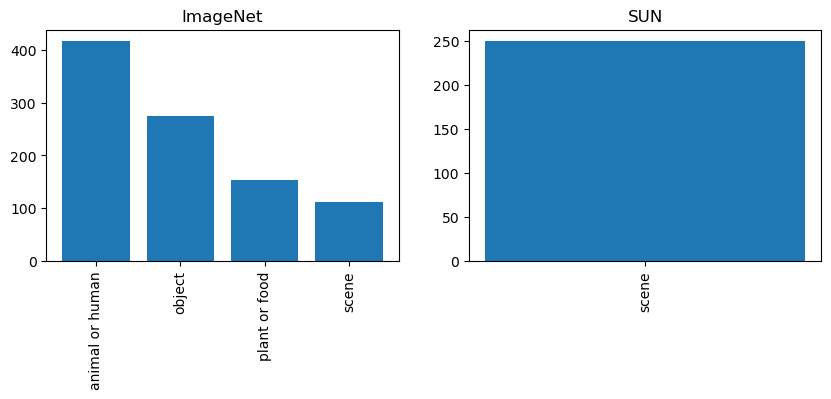

In [35]:
print(f"Final categories: {final_categories}")

imagenet_labels_dist = imagenet_final_df['final_super_label'].value_counts()
sun_labels_dist = sun_final_df['final_super_label'].value_counts()

print(f'\nNumber of original ImageNet labels: {len(imagenet_final_df)}')
print(f'Number of original SUN labels: {len(sun_final_df)}\n')

plt.subplots(1,2, figsize=(10,3))
plt.subplot(1,2,1)
plt.bar(imagenet_labels_dist.index, imagenet_labels_dist.values)
plt.title('ImageNet')
plt.xticks(rotation=90)
plt.subplot(1,2,2)
plt.bar(sun_labels_dist.index, sun_labels_dist.values)
plt.title('SUN')
plt.xticks(rotation=90)
plt.show()

In [36]:
# total distribution of the final categories in the 3 datasets together
tot_dist = pd.DataFrame({'ImageNet': imagenet_labels_dist, 'SUN': sun_labels_dist})
tot_dist.fillna(int(0), inplace=True)
tot_dist['sum'] = tot_dist.sum(axis=1)
tot_dist = tot_dist.sort_values(by='sum', ascending=False)
# put them as integer
tot_dist = tot_dist.astype(int)
tot_dist

,ImageNet,SUN,sum
final_super_label,,,
animal or human,418,0,418
scene,111,250,361
object,275,0,275
plant or food,154,0,154


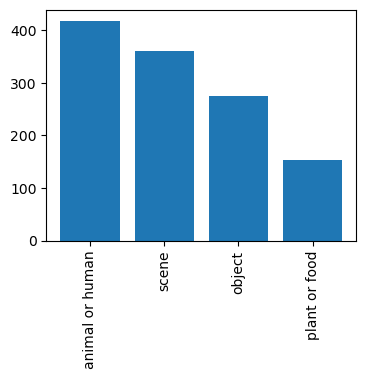

In [37]:
# plot distribution of the tot_dist
plt.figure(figsize=(4,3))
plt.bar(tot_dist.index, tot_dist['sum'])
plt.xticks(rotation=90)
plt.show()

The dataset is not balanced.

But NB: this is the distribution of the LABELS. Not of the presented images. Maybe the presented images will be balanced between the categories.

In [38]:
# Save the df as csv file
if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'complete_final_df.csv')):
    complete_final_df.to_csv(os.path.join(variables.BOLD5000_PATH,'complete_final_df.csv'), index=False)

In [39]:
sun_final_df.head(4)

,original_sun_name,final_super_label
0,readingroom,scene
1,office,scene
2,deck,scene
3,promenadeDeck,scene


In [40]:
imagenet_final_df.head(4)

,original_imagenet_id,original_imagenet_name,intermediate_step,final_super_label
0,n01440764,"tench, Tinca tinca",animal.n.01,animal or human
1,n01443537,"goldfish, Carassius auratus",animal.n.01,animal or human
2,n01484850,"great white shark, white shark, man-eater, man...",animal.n.01,animal or human
3,n01491361,"tiger shark, Galeocerdo cuvieri",animal.n.01,animal or human
